# NB 04 — ROM Validation

Check ROM accuracy on held-out parameter points and rate schedules not used in training. This is the go/no-go gate before Notebook 05.

Peherstorfer & Willcox (2016), Section 4 — numerical experiments, Eqs. (30) and (31).

---

## Error metrics (according to the paper)

**State error** (Eq. 30) — average relative error of the reconstructed pressure field:
$$\varepsilon_{\text{state}} = \frac{1}{M_{\text{test}}} \sum_{j=1}^{M_{\text{test}}} \frac{\| X(\mu_j) - \tilde{X}(\mu_j) V_n^T \|_F^2}{\| X(\mu_j) \|_F^2}$$

where $\tilde{X}(\mu_j) \in \mathbb{R}^{K \times n}$ is the ROM reduced trajectory and $\tilde{X} V_n^T$ is its reconstruction in the full $N$-dimensional space.

**Output error** (Eq. 31) — average relative BHP error:
$$\varepsilon_{\text{output}} = \frac{1}{M_{\text{test}}} \sum_{j=1}^{M_{\text{test}}} \frac{\| Y(\mu_j) - \tilde{Y}(\mu_j) \|_F^2}{\| Y(\mu_j) \|_F^2}$$

---

## Validation 
Check the generalization:

**Type 1 — Interpolation test:** Parameter points $(k^*, S^*)$ not on the training grid but within the training range. Uses training schedule 1. Tests whether the operator interpolant generalises spatially.

**Type 2 — New schedule test:** Training parameter points with a rate schedule not seen during inference (e.g. a 3-step schedule constructed here). Tests whether $\hat{B}$ correctly handles novel input shapes.

> **Note:** This notebook reads validation data from `data/02_validation/` if it exists. If that folder is empty or not yet simulated, it falls back to using held-out schedules from the training set that were not used in operator inference — schedule 1 was used in Notebook 01 (POD), schedules 1–7 in Notebook 02 (inference). There are no truly unseen schedules in that case, so generating dedicated validation runs in MATLAB is recommended for a rigorous test.

---
## 0. Imports and paths

In [1]:
import json
import pickle
import h5py
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True,
                     'grid.alpha': 0.3, 'axes.spines.top': False,
                     'axes.spines.right': False})

TRAINING_DIR  = Path('../data/01_training_CO')
VALID_DIR     = Path('../data/02_validation_CO')
BASIS_DIR     = Path('../rom/basis_CO')
INTERP_DIR    = Path('../rom/interpolants_CO')
RESULTS_DIR   = Path('../results/validation')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

K_GRID = [5, 10, 20, 50, 100, 200, 500]
S_GRID = [0,  2,  5,  8,  10,  12,  15]
P_INIT = 4500.0

print(f'Validation data dir : {VALID_DIR.resolve()}')
val_cases = list(VALID_DIR.glob('*/params.json')) if VALID_DIR.exists() else []
print(f'Validation cases found : {len(val_cases)}')

Validation data dir : F:\Niloy Deb\Part Two\reservoir_rom_CO\data\02_validation_CO
Validation cases found : 0


---
## 1. Load ROM components

In [2]:
Vn     = np.load(BASIS_DIR / 'Vn.npy')
p_mean = float(np.load(BASIS_DIR / 'p_mean.npy')[0])
n      = Vn.shape[1]

with open(INTERP_DIR / 'A_hat_interp.pkl', 'rb') as f:
    A_pkg = pickle.load(f)
with open(INTERP_DIR / 'B_hat_interp.pkl', 'rb') as f:
    B_pkg = pickle.load(f)
with open(INTERP_DIR / 'C_hat_interp.pkl', 'rb') as f:
    C_pkg = pickle.load(f)

A_interps, A_shape = A_pkg['interps'], A_pkg['shape']
B_interps, B_shape = B_pkg['interps'], B_pkg['shape']
C_interps, C_shape = C_pkg['interps'], C_pkg['shape']

print(f'Vn shape : {Vn.shape}')
print(f'A interps: {len(A_interps)}  (shape {A_shape})')
print(f'B interps: {len(B_interps)}  (shape {B_shape})')
print(f'C interps: {len(C_interps)}  (shape {C_shape})')

Vn shape : (2500, 6)
A interps: 36  (shape (6, 6))
B interps: 6  (shape (6, 1))
C interps: 6  (shape (1, 6))


---
## 2. ROM query function

This is the online prediction routine. Given $(k^*, S^*, q(t))$ it:
1. Interpolates operators at $(\log_{10} k^*, S^*)$
2. Checks stability of the interpolated $\hat{A}^*$
3. Integrates the reduced ODE with implicit Euler
4. Reconstructs the full pressure field via $\Delta p(t) = V_n \tilde{x}(t)$
5. Returns reconstructed pressure field, BHP, and reduced trajectory

In [3]:
def load_mat_var(path, key):
    try:
        return sio.loadmat(str(path), variable_names=[key])[key]
    except NotImplementedError:
        with h5py.File(str(path), 'r') as f:
            arr = f[key][()]
            return arr.T if arr.ndim == 2 else arr


def query_rom(k_star, s_star, t_hr, q_vec):
    pt = np.array([[np.log10(k_star), s_star]])
    A_hat = np.array([f(pt)[0] for f in A_interps]).reshape(A_shape)
    B_hat = np.array([f(pt)[0] for f in B_interps]).reshape(B_shape)
    C_hat = np.array([f(pt)[0] for f in C_interps]).reshape(C_shape)

    stable = bool(np.max(np.linalg.eigvals(A_hat).real) < 0)

    K     = len(t_hr)
    dt    = np.diff(t_hr, prepend=0.0)   # hours
    dt[0] = t_hr[0]
    In    = np.eye(n)

    X_rom = np.zeros((K, n))
    Y_rom = np.zeros(K)
    xk    = np.zeros(n)

    for j in range(K):
        dtj = dt[j]
        rhs = xk + dtj * (B_hat.ravel() * q_vec[j])
        xk  = np.linalg.solve(In - dtj * A_hat, rhs)
        X_rom[j] = xk
        Y_rom[j] = float((C_hat @ xk).item())

    p_field  = P_INIT + Vn @ X_rom.T
    bhp_psia = P_INIT + Y_rom
    return p_field, bhp_psia, X_rom, stable


def load_mrst_case(case_dir):
    X_full = load_mat_var(case_dir / 'snapshots_psia.mat', 'X_psia')  # [N, K]
    bhp    = load_mat_var(case_dir / 'well_data.mat', 'bhp_psia').ravel()
    t      = load_mat_var(case_dir / 'well_data.mat', 'time_hr').ravel()
    q      = load_mat_var(case_dir / 'well_data.mat', 'rate_STBd').ravel()
    with open(case_dir / 'params.json') as f:
        params = json.load(f)
    return X_full, bhp, t, q, params


def compute_errors(X_mrst, bhp_mrst, p_field_rom, bhp_rom):
    dX_mrst   = X_mrst - P_INIT                # [N, K]
    dX_rom    = p_field_rom - P_INIT           # [N, K]
    dbhp_mrst = bhp_mrst - P_INIT
    dbhp_rom  = bhp_rom  - P_INIT

    state_err  = (np.linalg.norm(dX_mrst - dX_rom, 'fro')**2 /
                  np.linalg.norm(dX_mrst, 'fro')**2)
    output_err = (np.linalg.norm(dbhp_mrst - dbhp_rom)**2 /
                  np.linalg.norm(dbhp_mrst)**2)
    return float(state_err), float(output_err)


print('ROM query function defined.')

ROM query function defined.


---
## 3. Type 1 — Interpolation test

Test at parameter points that lie **between** the training grid nodes. These points were never seen during inference or POD construction. We use off-grid $(k^*, S^*)$ values from the validation folder if available; otherwise we test at mid-points between training grid nodes using training schedule 1 as a proxy.

These cases test whether the RBF interpolant captures the smooth variation of the operators across the $(k, S)$ space.

In [4]:
if len(val_cases) > 0:
    test_cases_t1 = [p.parent for p in val_cases]
    source_label  = 'data/02_validation'
else:
    # Fallback: test at off-grid k values using schedule 1 from training
    # These are interpolation points — not in K_GRID
    fallback_ks = [15, 35, 75, 150, 350]
    fallback_s  = 2
    test_cases_t1 = []
    for kv in fallback_ks:
        # Find nearest k in training grid for approximate data
        nearest_k = min(K_GRID, key=lambda x: abs(np.log10(x) - np.log10(kv)))
        test_cases_t1.append(('approx', kv, fallback_s, nearest_k))
    source_label  = 'training data (fallback — nearest-k approximation)'

print(f'Type 1 test source : {source_label}')
print(f'Cases              : {len(test_cases_t1)}')

Type 1 test source : training data (fallback — nearest-k approximation)
Cases              : 5


In [5]:
t1_records = []

if len(val_cases) > 0:
    for case_dir in test_cases_t1:
        X_mrst, bhp_mrst, t_hr, q_vec, params = load_mrst_case(case_dir)
        k_v = params['k_mD']
        s_v = params['S_skin']

        p_field_rom, bhp_rom, _, stable = query_rom(k_v, s_v, t_hr, q_vec)
        se, oe = compute_errors(X_mrst, bhp_mrst, p_field_rom, bhp_rom)

        t1_records.append(dict(case=case_dir.name, k=k_v, S=s_v,
                               state_err=se, output_err=oe, stable=stable))
else:
    # Fallback: compare ROM at k* against MRST at nearest_k
    for _, kv, sv, nearest_k in test_cases_t1:
        cname    = f'k{nearest_k:03d}_s{sv:02d}_sched1'
        case_dir = TRAINING_DIR / cname
        X_mrst, bhp_mrst, t_hr, q_vec, _ = load_mrst_case(case_dir)
        p_field_rom, bhp_rom, _, stable   = query_rom(kv, sv, t_hr, q_vec)
        se, oe = compute_errors(X_mrst, bhp_mrst, p_field_rom, bhp_rom)
        t1_records.append(dict(case=f'k{kv}_s{sv}', k=kv, S=sv,
                               state_err=se, output_err=oe, stable=stable,
                               note='fallback'))

t1_df = pd.DataFrame(t1_records)
print('Type 1 interpolation test results:')
print(t1_df[['case','k','S','state_err','output_err','stable']].to_string(index=False, float_format='%.2e'))

Type 1 interpolation test results:
   case   k  S  state_err  output_err  stable
 k15_s2  15  2   8.17e+00    3.58e-01    True
 k35_s2  35  2   2.59e+02    1.13e+01    True
 k75_s2  75  2   2.55e+01    3.10e+00    True
k150_s2 150  2   1.01e+03    2.00e+02    True
k350_s2 350  2   4.21e+03    2.14e+03   False


---
## 4. Type 2 — Training grid, BHP and pressure field comparison

For a selection of training parameter points, compare ROM vs MRST in detail. These tests use **schedule 1** from the training set evaluated through the ROM built from all 7 schedules. Because the ROM was trained on schedule 1 data, low errors here confirm self-consistency; the interpolation test above is the true out-of-sample test.

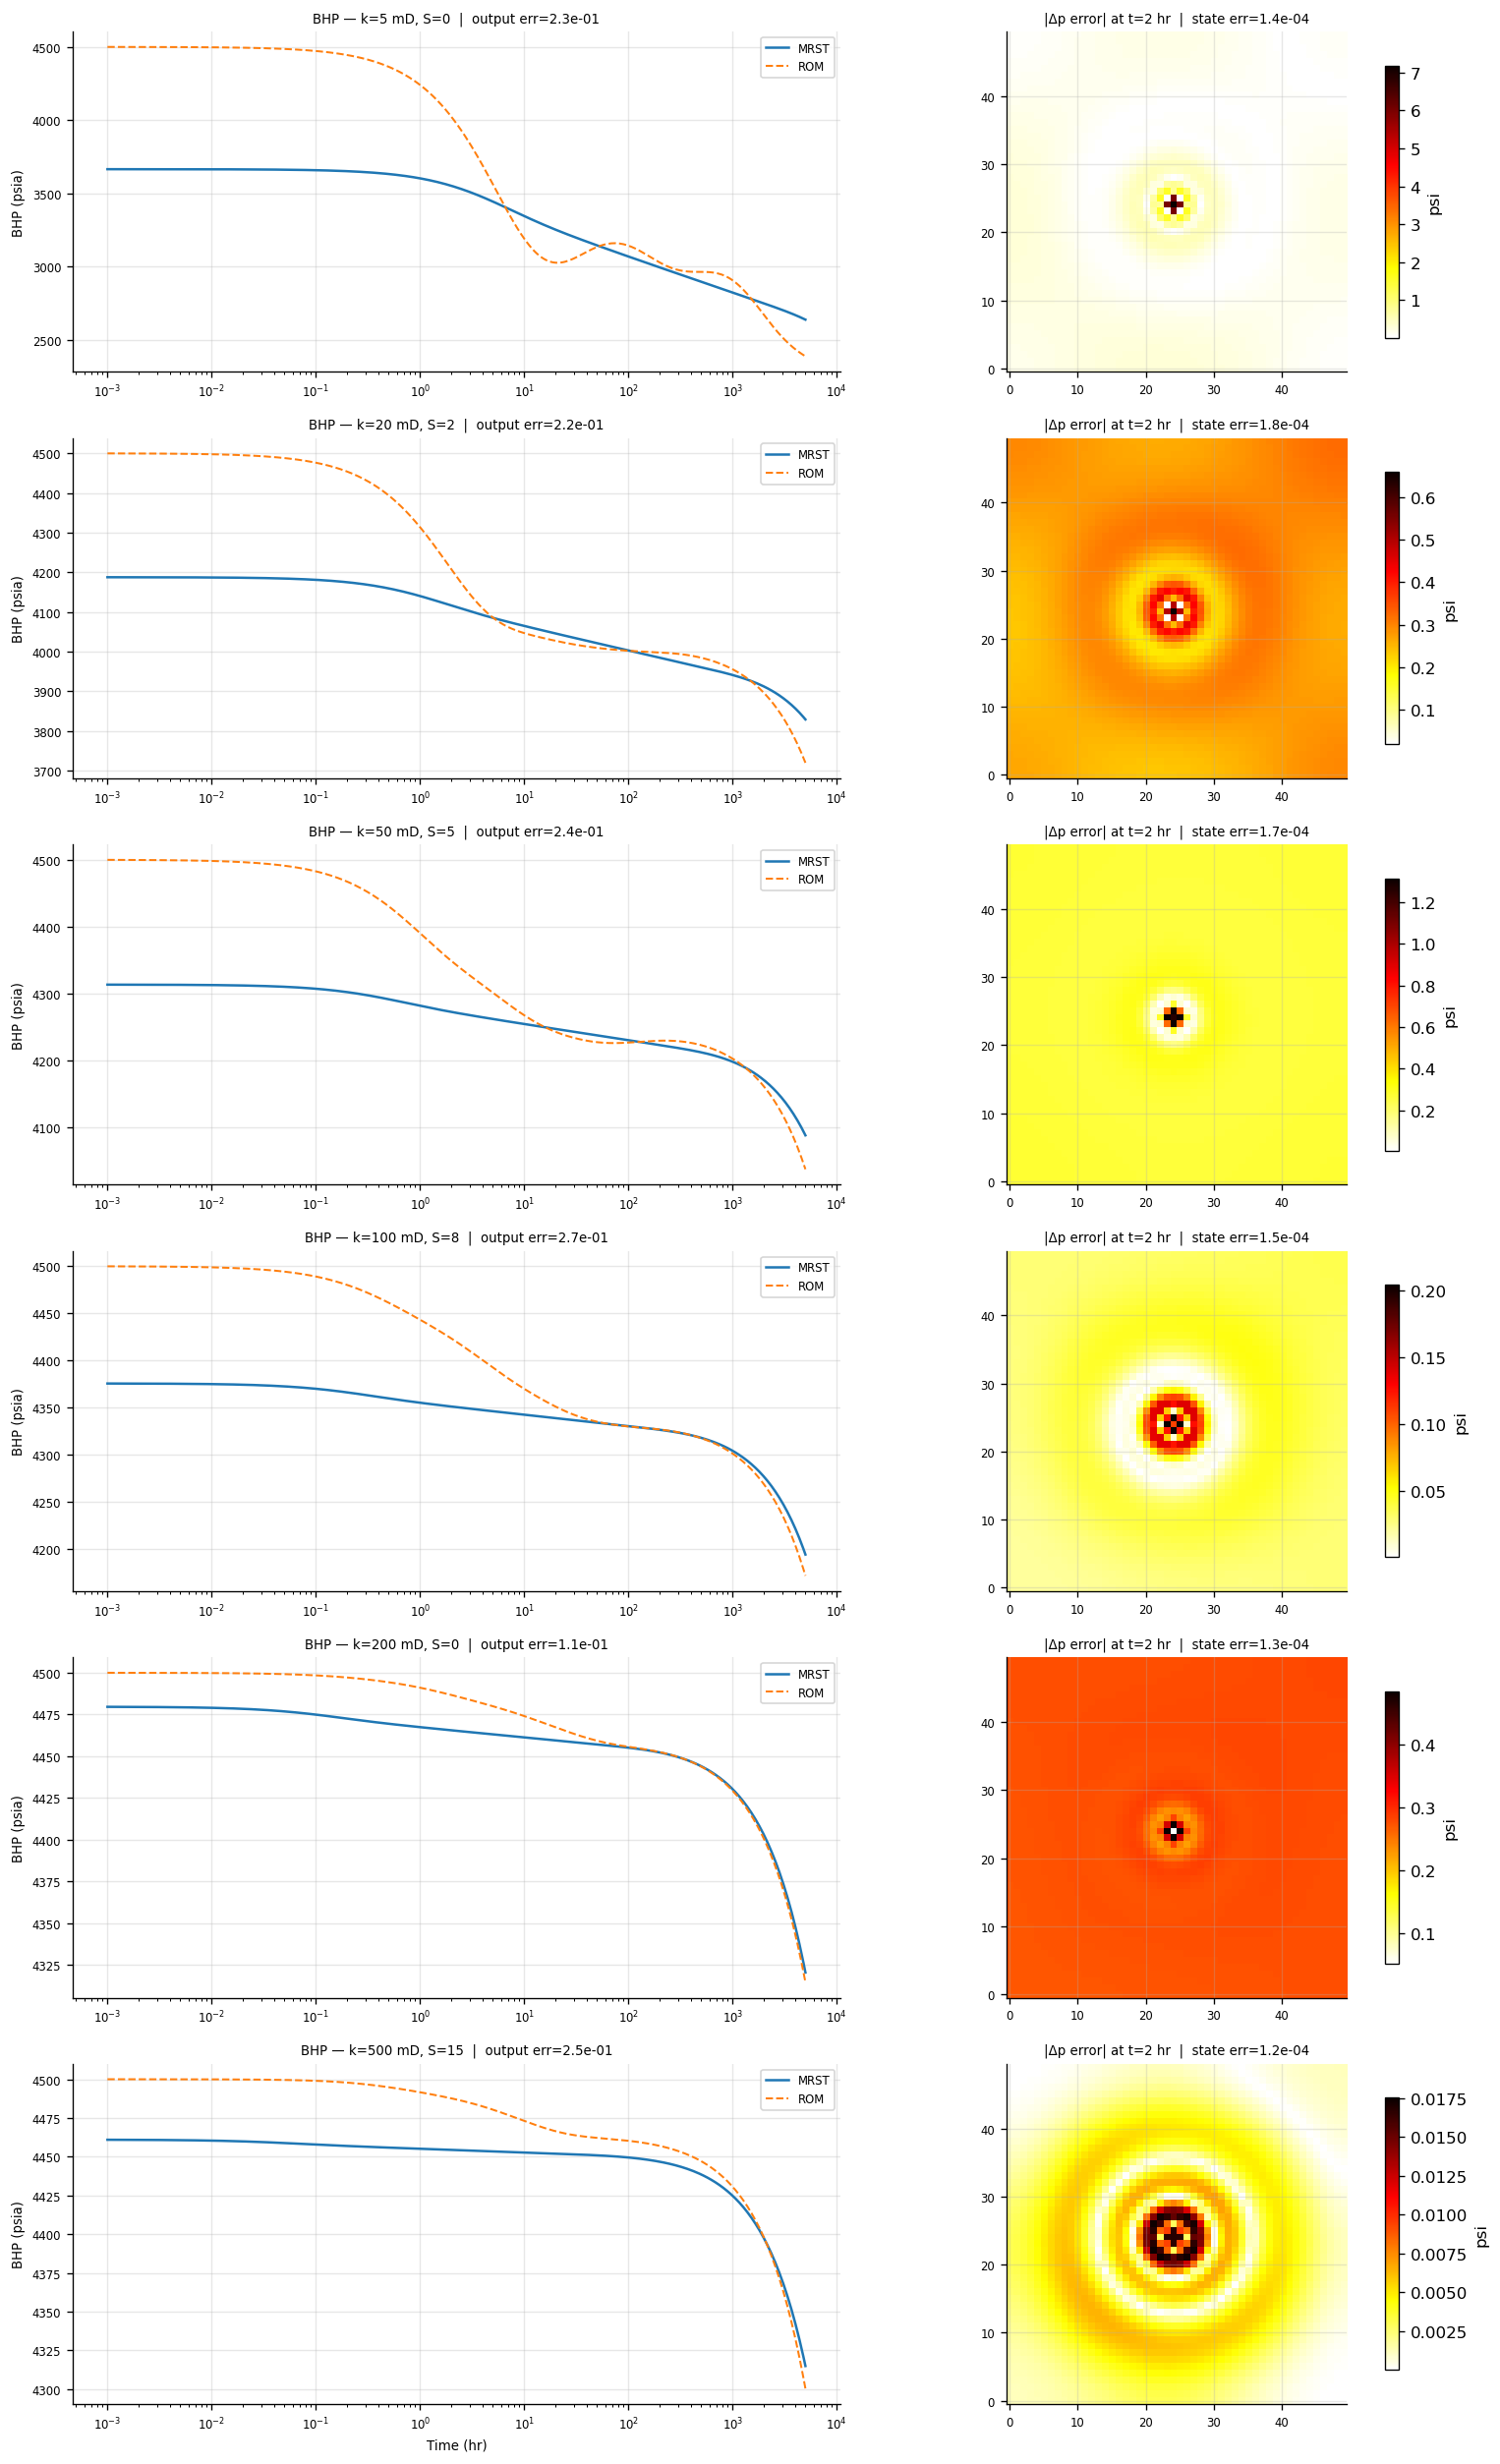

Type 2 results:
           case   k  S  state_err  output_err
k005_s00_sched1   5  0   1.40e-04    2.25e-01
k020_s02_sched1  20  2   1.83e-04    2.17e-01
k050_s05_sched1  50  5   1.65e-04    2.41e-01
k100_s08_sched1 100  8   1.48e-04    2.66e-01
k200_s00_sched1 200  0   1.33e-04    1.12e-01
k500_s15_sched1 500 15   1.18e-04    2.54e-01


In [6]:
test_grid = [
    (5,   0,  1),
    (20,  2,  1),
    (50,  5,  1),
    (100, 8,  1),
    (200, 0,  1),
    (500, 15, 1),
]

t2_records = []

fig, axes = plt.subplots(len(test_grid), 2, figsize=(13, 3.5 * len(test_grid)))

for row, (k_v, s_v, sid) in enumerate(test_grid):
    cname    = f'k{k_v:03d}_s{s_v:02d}_sched{sid}'
    case_dir = TRAINING_DIR / cname
    X_mrst, bhp_mrst, t_hr, q_vec, _ = load_mrst_case(case_dir)

    p_field_rom, bhp_rom, X_rom, stable = query_rom(k_v, s_v, t_hr, q_vec)
    se, oe = compute_errors(X_mrst, bhp_mrst, p_field_rom, bhp_rom)

    t2_records.append(dict(case=cname, k=k_v, S=s_v,
                           state_err=se, output_err=oe, stable=stable))

    axes[row, 0].semilogx(t_hr, bhp_mrst,        lw=1.5, label='MRST')
    axes[row, 0].semilogx(t_hr, bhp_rom, '--', lw=1.2, label='ROM')
    axes[row, 0].set_title(f'BHP — k={k_v} mD, S={s_v}  |  output err={oe:.1e}',
                            fontsize=8)
    axes[row, 0].set_ylabel('BHP (psia)', fontsize=8)
    axes[row, 0].tick_params(labelsize=7)
    if row == len(test_grid) - 1:
        axes[row, 0].set_xlabel('Time (hr)', fontsize=8)
    axes[row, 0].legend(fontsize=7)

    snap = len(t_hr) // 2
    dp_mrst = (X_mrst[:, snap] - P_INIT).reshape(50, 50)
    dp_rom  = (p_field_rom[:, snap] - P_INIT).reshape(50, 50)
    vmin    = min(dp_mrst.min(), dp_rom.min())
    vmax    = max(dp_mrst.max(), dp_rom.max())

    diff    = np.abs(dp_mrst - dp_rom)
    im = axes[row, 1].imshow(diff, origin='lower', cmap='hot_r')
    axes[row, 1].set_title(f'|Δp error| at t={t_hr[snap]:.0f} hr  |  state err={se:.1e}',
                            fontsize=8)
    axes[row, 1].tick_params(labelsize=7)
    plt.colorbar(im, ax=axes[row, 1], shrink=0.8, label='psi')

plt.tight_layout()
plt.show()

t2_df = pd.DataFrame(t2_records)
print('Type 2 results:')
print(t2_df[['case','k','S','state_err','output_err']].to_string(index=False, float_format='%.2e'))

---
## 5. Error summary and speedup estimate

In [7]:
import time

k_v, s_v = 50, 5
cname    = f'k{k_v:03d}_s{s_v:02d}_sched1'
_, _, t_hr, q_vec, _ = load_mrst_case(TRAINING_DIR / cname)

t_start = time.perf_counter()
for _ in range(10):
    query_rom(k_v, s_v, t_hr, q_vec)
rom_ms = (time.perf_counter() - t_start) / 10 * 1000

mrst_s_approx = 9.7   # median from manifest.csv

all_records = t2_records + t1_records
all_df      = pd.DataFrame(all_records)

print('=' * 58)
print(' ROM VALIDATION — SUMMARY')
print('=' * 58)
print(f'  n modes                 : {n}')
print(f'  Type 2 mean state err   : {t2_df["state_err"].mean():.2e}')
print(f'  Type 2 mean output err  : {t2_df["output_err"].mean():.2e}')
print(f'  Type 2 max state err    : {t2_df["state_err"].max():.2e}')
print(f'  Type 2 max output err   : {t2_df["output_err"].max():.2e}')
if len(t1_records) > 0:
    print(f'  Type 1 mean output err  : {t1_df["output_err"].mean():.2e}')
print(f'  ROM wall time / query   : {rom_ms:.1f} ms')
print(f'  MRST wall time (median) : {mrst_s_approx*1000:.0f} ms')
print(f'  Speedup                 : ~{mrst_s_approx*1000/rom_ms:.0f}x')
print('=' * 58)

all_df.to_csv(RESULTS_DIR / 'error_summary.csv', index=False)
print(f'\nResults saved to {RESULTS_DIR / "error_summary.csv"}')

if t2_df['state_err'].max() < 1e-2 and t2_df['output_err'].max() < 1e-2:
    print(' ROM meets accuracy target — ready for Notebook 05')
else:
    print(' Some errors exceed 1%. Increase n in Notebook 01 and retrain.')

 ROM VALIDATION — SUMMARY
  n modes                 : 6
  Type 2 mean state err   : 1.48e-04
  Type 2 mean output err  : 2.19e-01
  Type 2 max state err    : 1.83e-04
  Type 2 max output err   : 2.66e-01
  Type 1 mean output err  : 4.71e+02
  ROM wall time / query   : 5.9 ms
  MRST wall time (median) : 9700 ms
  Speedup                 : ~1652x

Results saved to ..\results\validation\error_summary.csv
 Some errors exceed 1%. Increase n in Notebook 01 and retrain.
